# Assignment #2: Heart Failure Classification

**Design philosophy of this notebook:**
- Preprocessing: scale only numerical columns (no leakage onto binary dummies)
- Evaluation: both weighted F1 (handles class imbalance) and binary F1 reported
- Hyperparameter tuning: full multi-dimensional grid search for every model
- AdaBoost: true weighted fitting (not resampling), early stopping, stability guards
- Random Forest: per-node feature subsampling with unique per-node RNG seed
- Required outputs: accuracy, F1, confusion matrices, most-confusing class analysis

## Section 1 — Imports & Global Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import itertools
from collections import Counter
from copy import deepcopy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
print("Imports complete. Random seed fixed at:", SEED)

Imports complete. Random seed fixed at: 42


## Section 2 — Dataset Loading & Exploratory Data Analysis

In [2]:
# ── Load dataset ─────────────────────────────────────────────────────────────
try:
    import kagglehub, os
    path = kagglehub.dataset_download('fedesoriano/heart-failure-prediction')
    csv_path = next(
        os.path.join(root, f)
        for root, _, files in os.walk(path)
        for f in files if f.endswith('.csv')
    )
    df = pd.read_csv(csv_path)
    print(f'Loaded via kagglehub: {csv_path}')
except Exception:
    df = pd.read_csv('heart.csv')
    print('Loaded from local heart.csv')

print(f'Dataset shape: {df.shape}')
df.head(10)

Loaded via kagglehub: C:\Users\OMAR\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1\heart.csv
Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [3]:
# ── Basic info & missing values ──────────────────────────────────────────────
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())
print('\nDescriptive statistics:')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


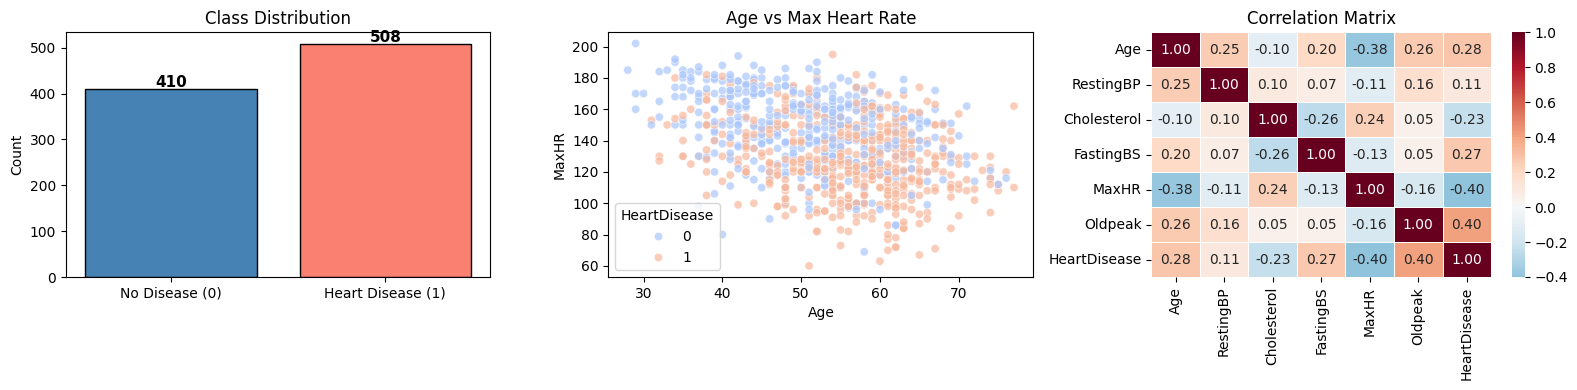

Class ratio — No Disease: 410 | Heart Disease: 508


In [4]:
# ── EDA: class distribution, scatter, correlation ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
ax = axes[0]
counts = df['HeartDisease'].value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
              color=['steelblue', 'salmon'], edgecolor='black')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 5, str(v),
            ha='center', fontsize=11, fontweight='bold')

# Age vs MaxHR
sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease',
                data=df, palette='coolwarm', alpha=0.7, ax=axes[1])
axes[1].set_title('Age vs Max Heart Rate')

# Correlation heatmap (numeric only)
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=axes[2])
axes[2].set_title('Correlation Matrix')

plt.tight_layout()
plt.show()
print(f'Class ratio — No Disease: {(df.HeartDisease==0).sum()} | Heart Disease: {(df.HeartDisease==1).sum()}')

## Section 3 — Preprocessing & Stratified 70 / 10 / 20 Split

**Key decisions:**
- `drop_first=False` in one-hot encoding — keeps all dummy columns for full interpretability (20 features).
- `StandardScaler` applied to the **6 numerical columns only** — binary dummies are already in [0,1] and should not be re-scaled.
- Scaler is **fit only on the training set** — prevents any leakage into validation or test.
- Two-step stratified split preserves the ~55/45 class ratio across all three subsets.

In [5]:
# ── One-hot encode categorical columns (drop_first=False → all dummies kept) ──
cat_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include='number').columns.drop('HeartDisease').tolist()
print('Categorical columns:', cat_cols)
print('Numerical columns:', numerical_cols)

df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=False)
print(f'\nShape after encoding: {df_enc.shape}')
print('Columns:', list(df_enc.columns))

Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Shape after encoding: (918, 21)
Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [6]:
# ── Features / target ────────────────────────────────────────────────────────
X = df_enc.drop('HeartDisease', axis=1).values.astype(float)
y = df_enc['HeartDisease'].values.astype(int)
feature_names = df_enc.drop('HeartDisease', axis=1).columns.tolist()
num_feature_indices = [feature_names.index(c) for c in numerical_cols]

print(f'X shape: {X.shape} | y shape: {y.shape}')
print(f'Class balance — 0 (No Disease): {(y==0).sum()} | 1 (Disease): {(y==1).sum()}')

X shape: (918, 20) | y shape: (918,)
Class balance — 0 (No Disease): 410 | 1 (Disease): 508


In [7]:
# ── Stratified 70 / 10 / 20 split ───────────────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=SEED, stratify=y_trainval
)

total = len(X)
print(f'{"Split":<12} {"Samples":>8} {"% Total":>8}  {"Class 0":>8}  {"Class 1":>8}')
print('-' * 55)
for name, Xs, ys in [('Train', X_train, y_train),
                      ('Val',   X_val,   y_val),
                      ('Test',  X_test,  y_test)]:
    print(f'{name:<12} {len(Xs):>8,} {len(Xs)/total*100:>7.1f}%  '
          f'{(ys==0).sum():>8}  {(ys==1).sum():>8}')

Split         Samples  % Total   Class 0   Class 1
-------------------------------------------------------
Train             642    69.9%       287       355
Val                92    10.0%        41        51
Test              184    20.0%        82       102


Scaling complete (numerical columns only).
Scaled columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Train mean (should be ~0): [ 0.  0.  0.  0. -0.  0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1.]


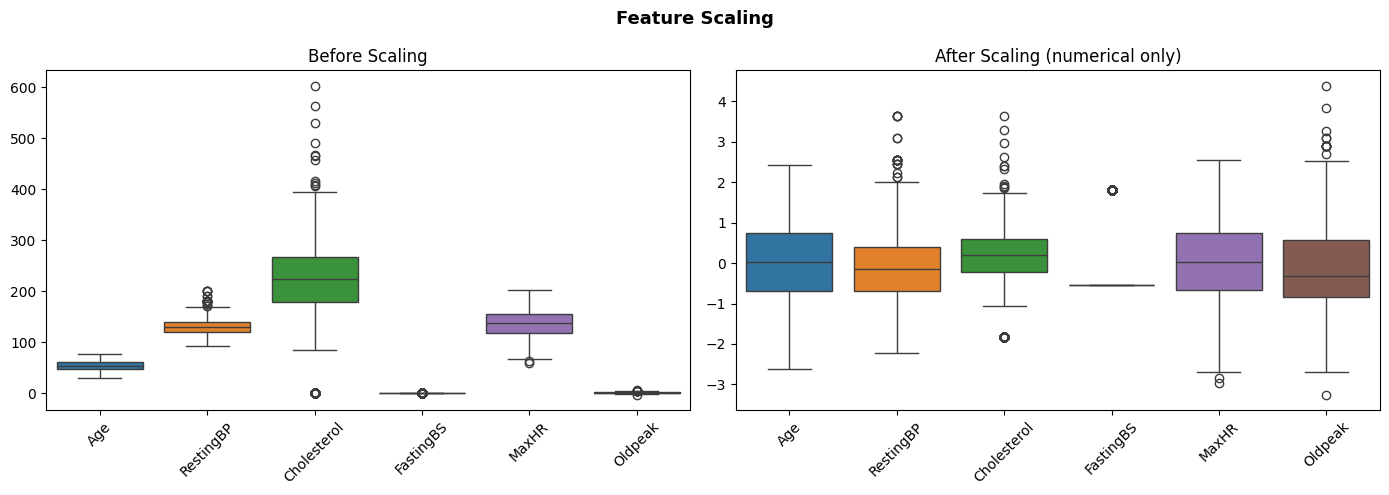

In [8]:
# ── Scale ONLY numerical columns (fit on train only) ─────────────────────────
scaler = StandardScaler()

X_train_s = X_train.copy()
X_val_s   = X_val.copy()
X_test_s  = X_test.copy()

X_train_s[:, num_feature_indices] = scaler.fit_transform(X_train[:, num_feature_indices])
X_val_s  [:, num_feature_indices] = scaler.transform(X_val  [:, num_feature_indices])
X_test_s [:, num_feature_indices] = scaler.transform(X_test [:, num_feature_indices])

print('Scaling complete (numerical columns only).')
print('Scaled columns:', numerical_cols)
print('Train mean (should be ~0):', X_train_s[:, num_feature_indices].mean(axis=0).round(4))
print('Train std  (should be ~1):', X_train_s[:, num_feature_indices].std(axis=0).round(4))

# Before / after scaling boxplots
before_df = pd.DataFrame(X_train[:, num_feature_indices], columns=numerical_cols)
after_df  = pd.DataFrame(X_train_s[:, num_feature_indices], columns=numerical_cols)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=before_df, ax=axes[0])
axes[0].set_title('Before Scaling', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=after_df, ax=axes[1])
axes[1].set_title('After Scaling (numerical only)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('Feature Scaling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 4 — Evaluation Utility: `ModelEvaluator`

A reusable class that computes **accuracy, weighted F1, binary F1, precision, recall**
and plots confusion matrices for any model across multiple splits.
Includes `find_most_confusing()` which satisfies the assignment's explicit requirement
to identify the most confusing class pair.

In [9]:
class ModelEvaluator:
    """
    Reusable evaluation wrapper for binary classifiers.
    Stores per-split results and provides confusion matrix plots
    plus explicit most-confusing-class identification.
    """
    def __init__(self, model_name: str):
        self.model_name = model_name
        self.results = {}

    def evaluate_split(self, y_true, y_pred, split_name: str):
        acc     = accuracy_score(y_true, y_pred)
        f1_w    = f1_score(y_true, y_pred, average='weighted')
        f1_bin  = f1_score(y_true, y_pred, average='binary')
        prec    = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec     = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        cm      = confusion_matrix(y_true, y_pred)
        self.results[split_name] = dict(
            acc=acc, f1_w=f1_w, f1_bin=f1_bin,
            prec=prec, rec=rec, cm=cm, y_pred=y_pred
        )
        return acc, f1_w, f1_bin, cm

    def print_metrics(self, split_name: str):
        r = self.results[split_name]
        print(f'  {split_name:5s} → Acc: {r["acc"]*100:.3f}%  '
              f'F1(weighted): {r["f1_w"]*100:.3f}%  '
              f'F1(binary): {r["f1_bin"]*100:.3f}%  '
              f'Prec: {r["prec"]*100:.3f}%  Recall: {r["rec"]*100:.3f}%')

    def plot_confusion_matrices(self, splits_y_true: dict, cmaps=None):
        n = len(splits_y_true)
        cmaps = cmaps or ['Blues', 'Greens', 'Oranges'][:n]
        fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
        if n == 1:
            axes = [axes]
        for ax, (split, y_true), cmap in zip(axes, splits_y_true.items(), cmaps):
            if split not in self.results:
                continue
            r = self.results[split]
            sns.heatmap(r['cm'], annot=True, fmt='d', cmap=cmap,
                        xticklabels=['No Disease', 'Disease'],
                        yticklabels=['No Disease', 'Disease'],
                        ax=ax, linewidths=0.5,
                        annot_kws={'size': 12, 'weight': 'bold'})
            ax.set_title(f'{self.model_name} — {split}\n'
                         f'Acc={r["acc"]*100:.2f}%  F1(w)={r["f1_w"]*100:.2f}%',
                         fontsize=11)
            ax.set_xlabel('Predicted')
            ax.set_ylabel('Actual')
        plt.suptitle(f'{self.model_name} — Confusion Matrices',
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.show()

    def find_most_confusing(self, split_name: str = 'Test'):
        """Identify the most frequent off-diagonal error (required by assignment)."""
        cm = self.results[split_name]['cm'].copy()
        np.fill_diagonal(cm, 0)
        idx = np.unravel_index(np.argmax(cm), cm.shape)
        labels = ['No Disease', 'Disease']
        print(f'  Most confusing ({split_name}): '
              f'True "{labels[idx[0]]}" predicted as "{labels[idx[1]]}" — {cm[idx]} times')

    def full_report(self, predict_fn, splits: dict):
        """
        splits = {'Train': (X, y), 'Val': (X, y), 'Test': (X, y)}
        """
        print(f'=== {self.model_name} Results ===')
        y_true_dict = {}
        for split_name, (Xs, ys) in splits.items():
            y_pred = predict_fn(Xs)
            self.evaluate_split(ys, y_pred, split_name)
            self.print_metrics(split_name)
            y_true_dict[split_name] = ys
        self.plot_confusion_matrices(y_true_dict)
        self.find_most_confusing('Test')
        print()
        print('  Detailed Test Classification Report:')
        print(classification_report(
            y_true_dict['Test'], self.results['Test']['y_pred'],
            target_names=['No Disease', 'Heart Disease']))

print('ModelEvaluator class defined.')

ModelEvaluator class defined.


## Section 5 — Decision Tree (From Scratch)

**Implementation details:**
- Entropy-based Information Gain for node splitting.
- **Midpoint thresholds** `(val[i] + val[i+1]) / 2` — avoids redundant splits at identical boundaries.
- Binary column detection — columns with only {0,1} values skip midpoint generation.
- `sample_weight` support via weighted entropy — required for correct AdaBoost integration.
- `max_features` parameter for per-node feature subsampling (used by Random Forest).
- Stopping criteria: `max_depth`, `min_samples_split`, `min_samples_leaf`, or pure node.

In [10]:
class Node:
    """Single node in the decision tree."""
    def __init__(self, feature=None, threshold=None,
                 left=None, right=None, value=None):
        self.feature   = feature     # column index to split on
        self.threshold = threshold   # numeric split threshold
        self.left      = left        # left child  (feature <= threshold)
        self.right     = right       # right child (feature >  threshold)
        self.value     = value       # majority class label (leaf nodes only)

    def is_leaf(self):
        return self.value is not None


class DecisionTree:
    """
    Binary Decision Tree using Information Gain (entropy).

    Parameters
    ----------
    max_depth         : int or None — maximum tree depth.
    min_samples_split : int — minimum samples required to split a node.
    min_samples_leaf  : int — minimum samples required in each leaf.
    max_features      : int or None — features considered per split (Random Forest).
    random_state      : int — seed for feature subsampling RNG.
    """

    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features=None, random_state=42):
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.max_features      = max_features
        self.random_state      = random_state
        self._rng              = None
        self.root              = None

    # ── Entropy helpers ──────────────────────────────────────────────────────
    @staticmethod
    def _entropy(y):
        counts = np.bincount(y)
        probs  = counts[counts > 0] / len(y)
        return -np.sum(probs * np.log2(probs))

    @staticmethod
    def _weighted_entropy(y, w):
        """Weighted entropy for AdaBoost sample weights."""
        total = w.sum()
        if total == 0:
            return 0.0
        entropy = 0.0
        for c in np.unique(y):
            p = w[y == c].sum() / total
            if p > 0:
                entropy -= p * np.log2(p)
        return entropy

    def _information_gain(self, y, y_l, y_r, w=None, w_l=None, w_r=None):
        if w is None:
            n, nl, nr = len(y), len(y_l), len(y_r)
            if nl == 0 or nr == 0:
                return 0.0
            return (self._entropy(y)
                    - (nl / n) * self._entropy(y_l)
                    - (nr / n) * self._entropy(y_r))
        else:
            wt, wl, wr = w.sum(), w_l.sum(), w_r.sum()
            if wl == 0 or wr == 0:
                return 0.0
            return (self._weighted_entropy(y, w)
                    - (wl / wt) * self._weighted_entropy(y_l, w_l)
                    - (wr / wt) * self._weighted_entropy(y_r, w_r))

    @staticmethod
    def _is_binary(values):
        return set(values).issubset({0, 1})

    def _get_thresholds(self, col):
        unique = np.sort(np.unique(col))
        if self._is_binary(unique):
            return unique
        return (unique[:-1] + unique[1:]) / 2 if len(unique) > 1 else unique

    # ── Split search ─────────────────────────────────────────────────────────
    def _best_split(self, X, y, w=None):
        n_features = X.shape[1]
        if self.max_features is not None and self.max_features < n_features:
            feature_indices = self._rng.choice(n_features,
                                               size=self.max_features,
                                               replace=False)
        else:
            feature_indices = range(n_features)

        best_gain, best_feat, best_thresh = -1, None, None
        for feat in feature_indices:
            for thresh in self._get_thresholds(X[:, feat]):
                mask = X[:, feat] <= thresh
                y_l, y_r = y[mask], y[~mask]
                if len(y_l) < self.min_samples_leaf or len(y_r) < self.min_samples_leaf:
                    continue
                if w is not None:
                    gain = self._information_gain(y, y_l, y_r, w, w[mask], w[~mask])
                else:
                    gain = self._information_gain(y, y_l, y_r)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh
        return best_feat, best_thresh

    # ── Tree construction ────────────────────────────────────────────────────
    def _majority_class(self, y, w=None):
        if w is None:
            return Counter(y).most_common(1)[0][0]
        class_weights = {c: w[y == c].sum() for c in np.unique(y)}
        return max(class_weights, key=class_weights.get)

    def _build(self, X, y, w, depth):
        if (len(np.unique(y)) == 1
                or len(y) < self.min_samples_split
                or (self.max_depth is not None and depth >= self.max_depth)):
            return Node(value=self._majority_class(y, w))

        feat, thresh = self._best_split(X, y, w)
        if feat is None:
            return Node(value=self._majority_class(y, w))

        mask = X[:, feat] <= thresh
        w_l  = w[mask]  if w is not None else None
        w_r  = w[~mask] if w is not None else None
        return Node(
            feature=feat, threshold=thresh,
            left =self._build(X[mask],  y[mask],  w_l,  depth + 1),
            right=self._build(X[~mask], y[~mask], w_r, depth + 1)
        )

    # ── Public API ───────────────────────────────────────────────────────────
    def fit(self, X, y, sample_weight=None):
        if isinstance(X, pd.DataFrame): X = X.values
        if isinstance(y, pd.Series):    y = y.values
        self._rng = np.random.RandomState(self.random_state)
        w = None
        if sample_weight is not None:
            w = np.array(sample_weight, dtype=float)
            w = w / w.sum()
        self.root = self._build(X, y.astype(int), w, 0)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        return (self._predict_one(x, node.left)
                if x[node.feature] <= node.threshold
                else self._predict_one(x, node.right))

    def predict(self, X):
        if isinstance(X, pd.DataFrame): X = X.values
        return np.array([self._predict_one(x, self.root) for x in X])


print('DecisionTree class defined.')

DecisionTree class defined.


In [11]:
# ── Hyperparameter tuning on VALIDATION set (3D grid) ────────────────────────
print('Tuning Decision Tree (depth × min_samples_split × min_samples_leaf)...')

param_grid_dt = list(itertools.product(
    [3, 5, 7, 10, 15, None],   # max_depth
    [2, 5, 10, 20],             # min_samples_split
    [1, 3, 5, 10, 15],          # min_samples_leaf
))
print(f'Total combinations: {len(param_grid_dt)}')

best_val_f1_dt, best_params_dt = -1, {}
dt_grid_results = []

for depth, mss, msl in param_grid_dt:
    dt = DecisionTree(max_depth=depth, min_samples_split=mss, min_samples_leaf=msl)
    dt.fit(X_train_s, y_train)
    val_f1   = f1_score(y_val,   dt.predict(X_val_s),   average='weighted')
    train_f1 = f1_score(y_train, dt.predict(X_train_s), average='weighted')
    dt_grid_results.append({'max_depth': depth, 'mss': mss, 'msl': msl,
                             'val_f1': val_f1, 'train_f1': train_f1})
    if val_f1 > best_val_f1_dt:
        best_val_f1_dt = val_f1
        best_params_dt = {'max_depth': depth, 'mss': mss, 'msl': msl}

df_dt_grid = pd.DataFrame(dt_grid_results).sort_values('val_f1', ascending=False)
print('\nTop 10 combinations:')
print(df_dt_grid.head(10).to_string(index=False))
print(f'\nBest: {best_params_dt}  Val F1(weighted)={best_val_f1_dt*100:.3f}%')

Tuning Decision Tree (depth × min_samples_split × min_samples_leaf)...
Total combinations: 120

Top 10 combinations:
 max_depth  mss  msl   val_f1  train_f1
       5.0    2   10 0.858509  0.874913
       5.0   20   10 0.858509  0.874913
       5.0   10   10 0.858509  0.874913
       5.0    5   10 0.858509  0.874913
       5.0    2   15 0.858031  0.870119
       5.0    5   15 0.858031  0.870119
       5.0   20   15 0.858031  0.870119
       5.0   10   15 0.858031  0.870119
       7.0    2   15 0.858031  0.870119
       7.0    5   15 0.858031  0.870119

Best: {'max_depth': 5, 'mss': 2, 'msl': 10}  Val F1(weighted)=85.851%


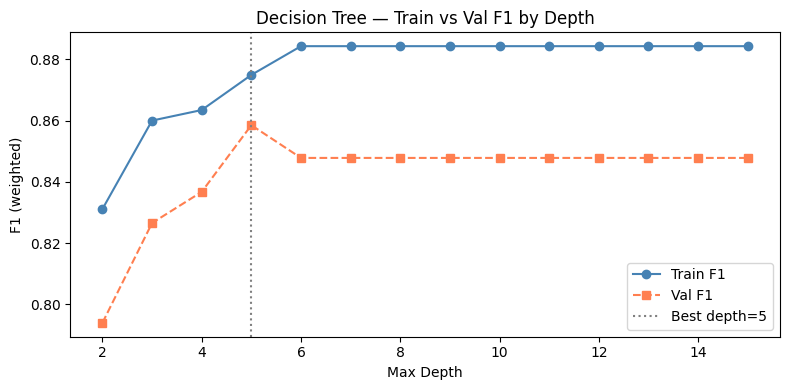

In [12]:
# ── Train/Val F1 vs depth (at best mss, msl) ─────────────────────────────────
depths_range = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
train_f1s, val_f1s = [], []
for d in depths_range:
    dt_tmp = DecisionTree(max_depth=d,
                          min_samples_split=best_params_dt['mss'],
                          min_samples_leaf=best_params_dt['msl'])
    dt_tmp.fit(X_train_s, y_train)
    train_f1s.append(f1_score(y_train, dt_tmp.predict(X_train_s), average='weighted'))
    val_f1s.append(f1_score(y_val,   dt_tmp.predict(X_val_s),   average='weighted'))

plt.figure(figsize=(8, 4))
plt.plot(depths_range, train_f1s, 'o-', label='Train F1', color='steelblue')
plt.plot(depths_range, val_f1s,   's--', label='Val F1',   color='coral')
best_depth_val = best_params_dt['max_depth'] or 15
plt.axvline(best_params_dt['max_depth'] if best_params_dt['max_depth'] else 15,
            color='gray', linestyle=':', label=f'Best depth={best_params_dt["max_depth"]}')
plt.xlabel('Max Depth')
plt.ylabel('F1 (weighted)')
plt.title('Decision Tree — Train vs Val F1 by Depth')
plt.legend()
plt.tight_layout()
plt.show()

=== Decision Tree Results ===
  Train → Acc: 87.539%  F1(weighted): 87.491%  F1(binary): 89.011%  Prec: 87.584%  Recall: 87.539%
  Val   → Acc: 85.870%  F1(weighted): 85.851%  F1(binary): 87.379%  Prec: 85.853%  Recall: 85.870%
  Test  → Acc: 84.239%  F1(weighted): 84.229%  F1(binary): 85.854%  Prec: 84.224%  Recall: 84.239%


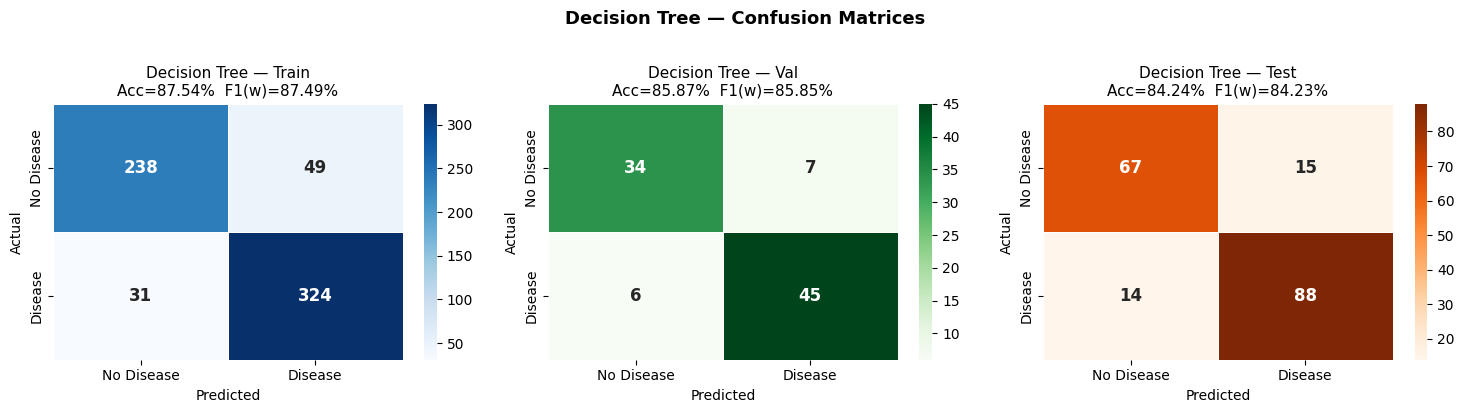

  Most confusing (Test): True "No Disease" predicted as "Disease" — 15 times

  Detailed Test Classification Report:
               precision    recall  f1-score   support

   No Disease       0.83      0.82      0.82        82
Heart Disease       0.85      0.86      0.86       102

     accuracy                           0.84       184
    macro avg       0.84      0.84      0.84       184
 weighted avg       0.84      0.84      0.84       184



In [13]:
# ── Train final Decision Tree & evaluate ─────────────────────────────────────
dt_final = DecisionTree(max_depth=best_params_dt['max_depth'],
                        min_samples_split=best_params_dt['mss'],
                        min_samples_leaf=best_params_dt['msl'])
dt_final.fit(X_train_s, y_train)

dt_eval = ModelEvaluator('Decision Tree')
dt_eval.full_report(
    dt_final.predict,
    {'Train': (X_train_s, y_train),
     'Val':   (X_val_s,   y_val),
     'Test':  (X_test_s,  y_test)}
)

## Section 6 — Bagging Ensemble (From Scratch)

**Algorithm:** Bootstrap Aggregating — each base learner is trained on a bootstrap sample
(sampled with replacement) of size `max_samples × n`. Final prediction is majority vote.  
**Base learner:** our own `DecisionTree` implementation above.  
**Tuning:** full 5-dimensional grid search — ensemble optimal depth/regularisation
differs from a standalone tree because averaging itself acts as a regulariser.

In [14]:
class BaggingClassifier:
    """
    Bootstrap Aggregating using DecisionTree as base learner.

    Parameters
    ----------
    n_estimators      : number of trees.
    max_samples       : fraction of training data per bootstrap (0 < x <= 1).
    max_depth         : tree depth per estimator.
    min_samples_split : minimum samples to split a node.
    min_samples_leaf  : minimum samples per leaf.
    random_state      : master seed.
    """

    def __init__(self, n_estimators=50, max_samples=1.0,
                 max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, random_state=42):
        self.n_estimators      = n_estimators
        self.max_samples       = max_samples
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.random_state      = random_state
        self.trees             = []

    def fit(self, X, y):
        rng  = np.random.RandomState(self.random_state)
        n    = len(y)
        sz   = max(1, int(self.max_samples * n))
        self.trees = []
        for _ in range(self.n_estimators):
            idx  = rng.choice(n, size=sz, replace=True)
            tree = DecisionTree(max_depth=self.max_depth,
                                min_samples_split=self.min_samples_split,
                                min_samples_leaf=self.min_samples_leaf)
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)
        return self

    def predict(self, X):
        preds = np.array([t.predict(X) for t in self.trees])
        return np.apply_along_axis(
            lambda col: np.bincount(col.astype(int)).argmax(),
            axis=0, arr=preds
        )


print('BaggingClassifier defined.')

BaggingClassifier defined.


In [15]:
# ── Full 5D hyperparameter grid for Bagging ──────────────────────────────────
# NOTE: We do NOT inherit DT params — optimal ensemble params differ from solo tree.
bag_param_grid = list(itertools.product(
    [10, 30, 50],    # n_estimators
    [0.6, 0.8],      # max_samples
    [5, 10],         # max_depth
    [2, 5, 10],      # min_samples_split
    [1, 3, 5],       # min_samples_leaf
))
print(f'Total Bagging combinations: {len(bag_param_grid)}')

best_val_f1_bag, best_params_bag = -1, {}
bag_grid_results = []

for i, (n_est, ms, depth, mss, msl) in enumerate(bag_param_grid):
    bag = BaggingClassifier(n_estimators=n_est, max_samples=ms,
                            max_depth=depth, min_samples_split=mss,
                            min_samples_leaf=msl, random_state=SEED)
    bag.fit(X_train_s, y_train)
    val_f1   = f1_score(y_val,   bag.predict(X_val_s),   average='weighted')
    train_f1 = f1_score(y_train, bag.predict(X_train_s), average='weighted')
    bag_grid_results.append({'n_est': n_est, 'ms': ms, 'depth': depth,
                              'mss': mss, 'msl': msl,
                              'val_f1': val_f1, 'train_f1': train_f1})
    if val_f1 > best_val_f1_bag:
        best_val_f1_bag = val_f1
        best_params_bag = {'n_estimators': n_est, 'max_samples': ms,
                           'max_depth': depth, 'mss': mss, 'msl': msl}
    if (i + 1) % 50 == 0:
        print(f'  Evaluated {i+1}/{len(bag_param_grid)}...')

df_bag_grid = pd.DataFrame(bag_grid_results).sort_values('val_f1', ascending=False)
print('\nTop 10 Bagging combinations:')
print(df_bag_grid.head(10).to_string(index=False))
print(f'\nBest: {best_params_bag}  Val F1(weighted)={best_val_f1_bag*100:.3f}%')

Total Bagging combinations: 108
  Evaluated 50/108...
  Evaluated 100/108...

Top 10 Bagging combinations:
 n_est  ms  depth  mss  msl   val_f1  train_f1
    50 0.6     10    2    5 0.869565  0.917339
    50 0.6     10    5    5 0.869565  0.917339
    50 0.6     10   10    5 0.869565  0.917339
    50 0.8     10   10    3 0.869565  0.939198
    10 0.8      5    5    1 0.859048  0.906542
    10 0.8      5    2    1 0.859048  0.904968
    30 0.6     10    5    5 0.858847  0.923608
    30 0.6     10    2    5 0.858847  0.923608
    10 0.6      5   10    3 0.858847  0.892606
    10 0.6      5    5    5 0.858847  0.887812

Best: {'n_estimators': 50, 'max_samples': 0.6, 'max_depth': 10, 'mss': 2, 'msl': 5}  Val F1(weighted)=86.957%


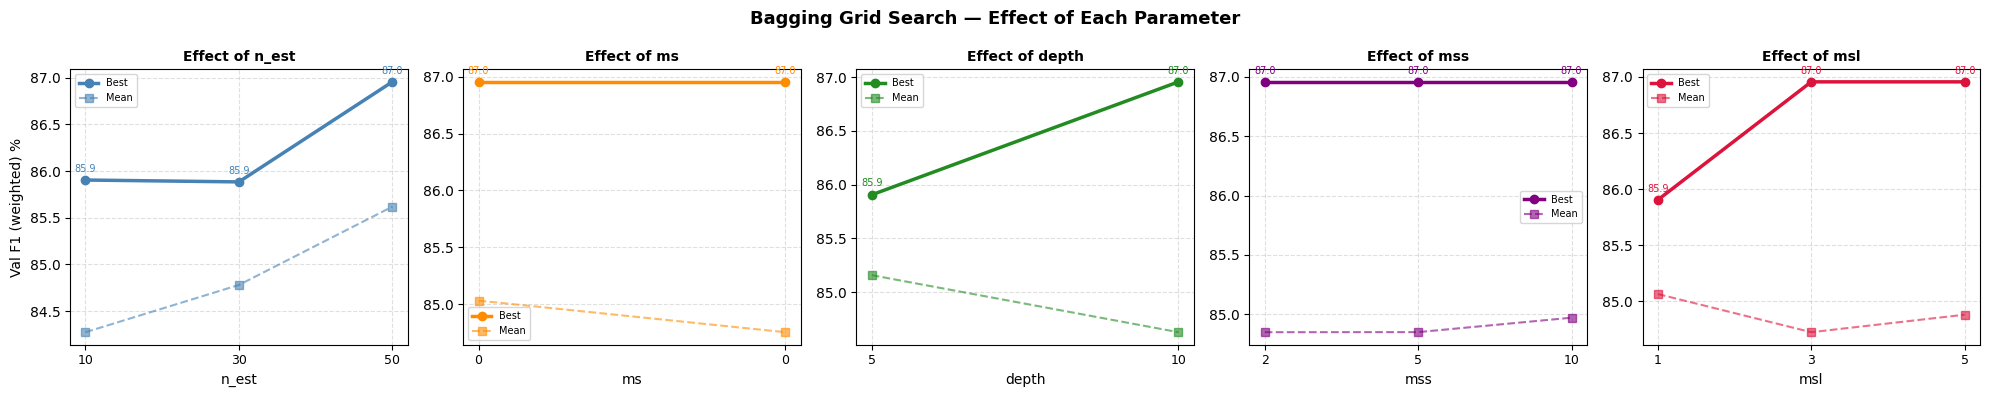

In [16]:
# ── Effect-of-each-parameter visualisation ───────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
param_cols = [('n_est', 'steelblue'), ('ms', 'darkorange'), ('depth', 'forestgreen'),
              ('mss', 'purple'), ('msl', 'crimson')]
for ax, (col, color) in zip(axes, param_cols):
    vals = sorted(df_bag_grid[col].unique(), key=lambda x: (x is None, x))
    best_v = [df_bag_grid[df_bag_grid[col]==v]['val_f1'].max() for v in vals]
    mean_v = [df_bag_grid[df_bag_grid[col]==v]['val_f1'].mean() for v in vals]
    xlbls  = [str(int(v)) if v is not None else 'None' for v in vals]
    ax.plot(range(len(vals)), [a*100 for a in best_v], marker='o', color=color,
            linewidth=2.5, label='Best')
    ax.plot(range(len(vals)), [a*100 for a in mean_v], marker='s', color=color,
            linewidth=1.5, linestyle='--', alpha=0.6, label='Mean')
    for i, (xl, ba) in enumerate(zip(xlbls, best_v)):
        ax.annotate(f'{ba*100:.1f}', (i, ba*100), textcoords='offset points',
                    xytext=(0, 6), ha='center', fontsize=7, color=color)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(xlbls, fontsize=9)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Val F1 (weighted) %' if ax == axes[0] else '')
    ax.set_title(f'Effect of {col}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Bagging Grid Search — Effect of Each Parameter',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Bagging Results ===
  Train → Acc: 91.745%  F1(weighted): 91.734%  F1(binary): 92.608%  Prec: 91.745%  Recall: 91.745%
  Val   → Acc: 86.957%  F1(weighted): 86.957%  F1(binary): 88.235%  Prec: 86.957%  Recall: 86.957%
  Test  → Acc: 84.783%  F1(weighted): 84.739%  F1(binary): 86.538%  Prec: 84.776%  Recall: 84.783%


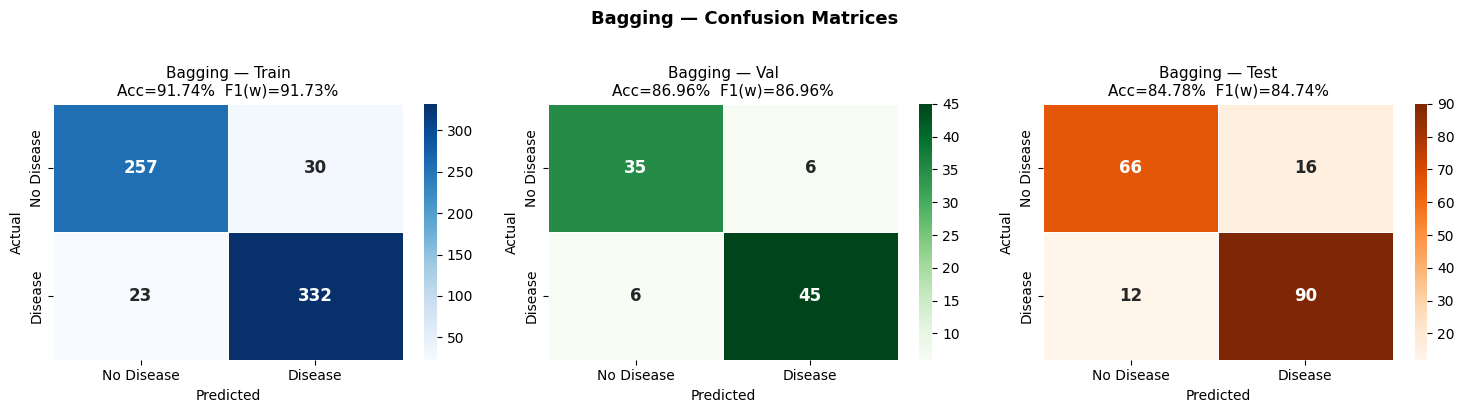

  Most confusing (Test): True "No Disease" predicted as "Disease" — 16 times

  Detailed Test Classification Report:
               precision    recall  f1-score   support

   No Disease       0.85      0.80      0.82        82
Heart Disease       0.85      0.88      0.87       102

     accuracy                           0.85       184
    macro avg       0.85      0.84      0.85       184
 weighted avg       0.85      0.85      0.85       184



In [17]:
# ── Train final Bagging model & evaluate ─────────────────────────────────────
bag_final = BaggingClassifier(
    n_estimators=best_params_bag['n_estimators'],
    max_samples=best_params_bag['max_samples'],
    max_depth=best_params_bag['max_depth'],
    min_samples_split=best_params_bag['mss'],
    min_samples_leaf=best_params_bag['msl'],
    random_state=SEED
)
bag_final.fit(X_train_s, y_train)

bag_eval = ModelEvaluator('Bagging')
bag_eval.full_report(
    bag_final.predict,
    {'Train': (X_train_s, y_train),
     'Val':   (X_val_s,   y_val),
     'Test':  (X_test_s,  y_test)}
)

## Section 7 — AdaBoost Ensemble (From Scratch)

**Algorithm:** Sequentially trains weak learners with adaptive sample weights.

**Key implementation choices:**
- **True weighted fitting** — sample weights are passed directly into the tree's weighted entropy
  calculation, not approximated by resampling. This is the mathematically correct AdaBoost.
- **Stability guard** — skips any stump with weighted error ≥ 0.5 (worse than random), which
  would produce negative α and degrade the ensemble.
- **Early stopping** — monitors validation F1 each round; restores the best model after `patience`
  rounds without improvement.
- **Stump depth tuning** — the assignment says "depth-1 stump or shallow tree"; we tune {1, 2, 3}.
- Labels converted to {−1, +1} internally for the AdaBoost weight update formula.

In [18]:
class AdaBoostClassifier:
    """
    AdaBoost with DecisionTree weak learners.

    True weighted fitting: sample weights flow into weighted entropy in the DT,
    not into a resampling step. This matches the original Freund & Schapire algorithm.

    Parameters
    ----------
    n_estimators : maximum boosting rounds.
    stump_depth  : depth of each weak learner (1 = decision stump).
    patience     : early-stopping patience (rounds without val F1 improvement).
    """

    def __init__(self, n_estimators=100, stump_depth=1, patience=10):
        self.n_estimators  = n_estimators
        self.stump_depth   = stump_depth
        self.patience      = patience
        self.stumps        = []
        self.alphas        = []
        self._train_errors = []
        self._val_errors   = []

    def _to_pm(self, y): return np.where(y == 0, -1,  1).astype(float)
    def _to_01(self, y): return np.where(y <= 0,  0,  1).astype(int)

    def fit(self, X, y, X_val=None, y_val=None):
        y_pm = self._to_pm(y)
        n    = len(y_pm)
        w    = np.ones(n) / n

        self.stumps, self.alphas = [], []
        self._train_errors, self._val_errors = [], []
        best_val_f1, no_improve = -1, 0
        best_stumps, best_alphas = [], []

        for t in range(self.n_estimators):
            # Train weak learner with current sample weights (true weighted fit)
            stump = DecisionTree(max_depth=self.stump_depth, min_samples_split=2)
            stump.fit(X, self._to_01(y_pm), sample_weight=w)

            pred_pm = self._to_pm(stump.predict(X))

            # Weighted error
            err = np.dot(w, (pred_pm != y_pm).astype(float)) / w.sum()
            err = np.clip(err, 1e-10, 1 - 1e-10)

            # Skip stumps worse than random (stability guard)
            if err >= 0.5:
                continue

            alpha = 0.5 * np.log((1 - err) / err)

            # Update and normalise weights
            w = w * np.exp(-alpha * y_pm * pred_pm)
            w /= w.sum()

            self.stumps.append(stump)
            self.alphas.append(alpha)

            train_f1 = f1_score(y, self._aggregate(X), average='weighted')
            self._train_errors.append(1 - train_f1)

            # Early stopping on validation F1
            if X_val is not None:
                val_f1 = f1_score(y_val, self._aggregate(X_val), average='weighted')
                self._val_errors.append(1 - val_f1)
                if val_f1 > best_val_f1:
                    best_val_f1  = val_f1
                    best_stumps  = list(self.stumps)
                    best_alphas  = list(self.alphas)
                    no_improve   = 0
                else:
                    no_improve += 1
                if no_improve >= self.patience:
                    print(f'  Early stopping at round {t+1}. '
                          f'Best val F1(weighted)={best_val_f1*100:.3f}%')
                    self.stumps = best_stumps
                    self.alphas = best_alphas
                    break
        return self

    def _aggregate(self, X):
        agg = np.zeros(len(X))
        for alpha, stump in zip(self.alphas, self.stumps):
            agg += alpha * self._to_pm(stump.predict(X))
        return self._to_01(np.sign(agg))

    def predict(self, X):
        return self._aggregate(X)


print('AdaBoostClassifier defined (true weighted fitting + early stopping).')

AdaBoostClassifier defined (true weighted fitting + early stopping).


In [19]:
# ── Tune n_estimators × stump_depth on validation set ────────────────────────
ada_param_grid = list(itertools.product([25, 50, 100, 200], [1, 2, 3]))
print(f'Total AdaBoost combinations: {len(ada_param_grid)}')

best_val_f1_ada, best_params_ada = -1, {}
ada_grid_results = []

for rounds, depth in ada_param_grid:
    ada = AdaBoostClassifier(n_estimators=rounds, stump_depth=depth, patience=10)
    ada.fit(X_train_s, y_train, X_val_s, y_val)
    val_f1   = f1_score(y_val,   ada.predict(X_val_s),   average='weighted')
    train_f1 = f1_score(y_train, ada.predict(X_train_s), average='weighted')
    ada_grid_results.append({'rounds': rounds, 'stump_depth': depth,
                              'val_f1': val_f1, 'train_f1': train_f1})
    print(f'  rounds={rounds:>3}  depth={depth}  train_f1={train_f1*100:.2f}%  val_f1={val_f1*100:.2f}%')
    if val_f1 > best_val_f1_ada:
        best_val_f1_ada = val_f1
        best_params_ada = {'n_estimators': rounds, 'stump_depth': depth}

df_ada_grid = pd.DataFrame(ada_grid_results).sort_values('val_f1', ascending=False)
print(f'\nBest: {best_params_ada}  Val F1(weighted)={best_val_f1_ada*100:.3f}%')

Total AdaBoost combinations: 12
  Early stopping at round 17. Best val F1(weighted)=84.783%
  rounds= 25  depth=1  train_f1=85.48%  val_f1=84.78%
  Early stopping at round 15. Best val F1(weighted)=80.472%
  rounds= 25  depth=2  train_f1=85.97%  val_f1=80.47%
  Early stopping at round 16. Best val F1(weighted)=86.957%
  rounds= 25  depth=3  train_f1=89.25%  val_f1=86.96%
  Early stopping at round 17. Best val F1(weighted)=84.783%
  rounds= 50  depth=1  train_f1=85.48%  val_f1=84.78%
  Early stopping at round 15. Best val F1(weighted)=80.472%
  rounds= 50  depth=2  train_f1=85.97%  val_f1=80.47%
  Early stopping at round 16. Best val F1(weighted)=86.957%
  rounds= 50  depth=3  train_f1=89.25%  val_f1=86.96%
  Early stopping at round 17. Best val F1(weighted)=84.783%
  rounds=100  depth=1  train_f1=85.48%  val_f1=84.78%
  Early stopping at round 15. Best val F1(weighted)=80.472%
  rounds=100  depth=2  train_f1=85.97%  val_f1=80.47%
  Early stopping at round 16. Best val F1(weighted)=86.9

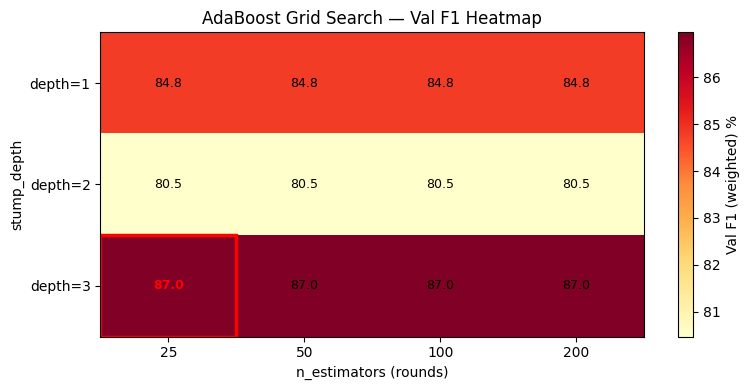

In [20]:
# ── AdaBoost 2D heatmap (rounds × stump_depth) ───────────────────────────────
round_vals = sorted(df_ada_grid['rounds'].unique())
depth_vals = sorted(df_ada_grid['stump_depth'].unique())

acc_mat = np.array([
    [df_ada_grid[(df_ada_grid['rounds']==r) &
                 (df_ada_grid['stump_depth']==d)]['val_f1'].values[0] * 100
     for r in round_vals]
    for d in depth_vals
])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(acc_mat, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(round_vals)))
ax.set_xticklabels(round_vals)
ax.set_yticks(range(len(depth_vals)))
ax.set_yticklabels([f'depth={d}' for d in depth_vals])
ax.set_xlabel('n_estimators (rounds)')
ax.set_ylabel('stump_depth')
ax.set_title('AdaBoost Grid Search — Val F1 Heatmap')
plt.colorbar(im, ax=ax, label='Val F1 (weighted) %')
for i, d in enumerate(depth_vals):
    for j, r in enumerate(round_vals):
        v = acc_mat[i, j]
        is_best = (r == best_params_ada['n_estimators'] and d == best_params_ada['stump_depth'])
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9,
                fontweight='bold' if is_best else 'normal',
                color='red' if is_best else 'black')
        if is_best:
            ax.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1,
                         fill=False, edgecolor='red', linewidth=2.5))
plt.tight_layout()
plt.show()

  Early stopping at round 16. Best val F1(weighted)=86.957%
=== AdaBoost Results ===
  Train → Acc: 89.252%  F1(weighted): 89.247%  F1(binary): 90.323%  Prec: 89.245%  Recall: 89.252%
  Val   → Acc: 86.957%  F1(weighted): 86.957%  F1(binary): 88.235%  Prec: 86.957%  Recall: 86.957%
  Test  → Acc: 85.326%  F1(weighted): 85.366%  F1(binary): 86.294%  Prec: 85.652%  Recall: 85.326%


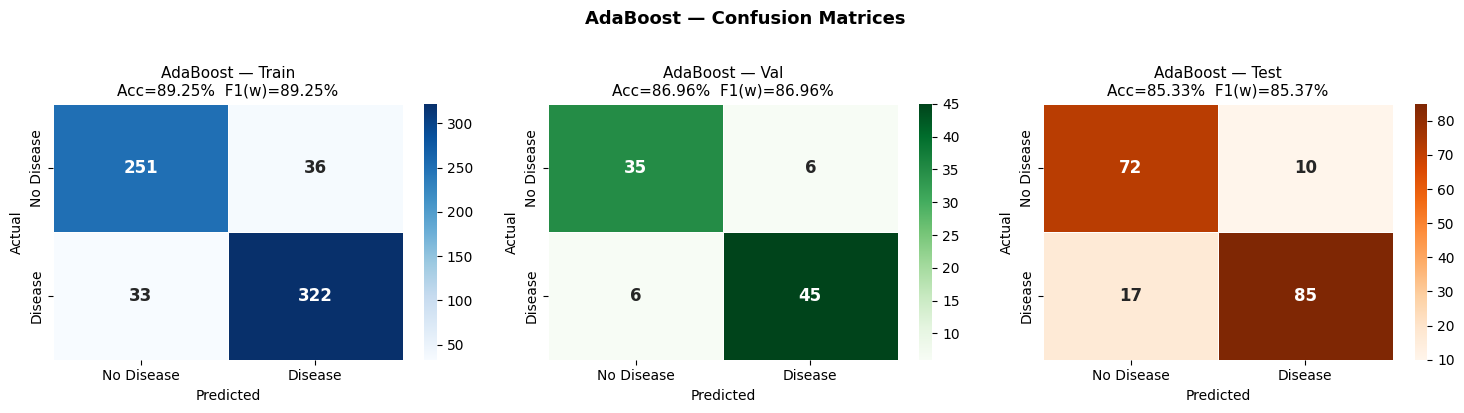

  Most confusing (Test): True "Disease" predicted as "No Disease" — 17 times

  Detailed Test Classification Report:
               precision    recall  f1-score   support

   No Disease       0.81      0.88      0.84        82
Heart Disease       0.89      0.83      0.86       102

     accuracy                           0.85       184
    macro avg       0.85      0.86      0.85       184
 weighted avg       0.86      0.85      0.85       184



In [21]:
# ── Train final AdaBoost model & evaluate ────────────────────────────────────
ada_final = AdaBoostClassifier(
    n_estimators=best_params_ada['n_estimators'],
    stump_depth=best_params_ada['stump_depth'],
    patience=10
)
ada_final.fit(X_train_s, y_train, X_val_s, y_val)

ada_eval = ModelEvaluator('AdaBoost')
ada_eval.full_report(
    ada_final.predict,
    {'Train': (X_train_s, y_train),
     'Val':   (X_val_s,   y_val),
     'Test':  (X_test_s,  y_test)}
)

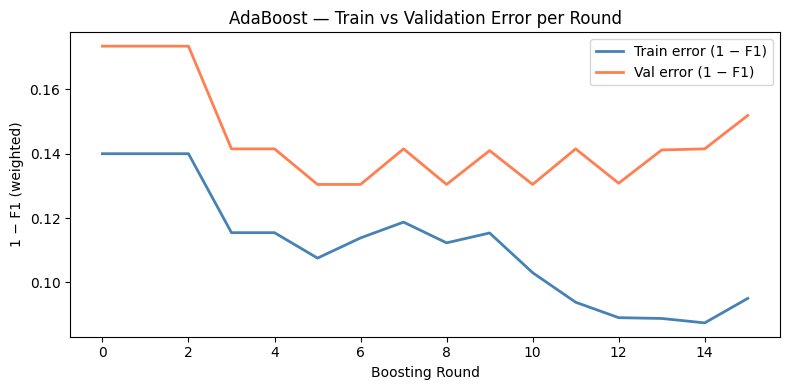

In [22]:
# ── AdaBoost train vs validation error curve ─────────────────────────────────
if ada_final._train_errors and ada_final._val_errors:
    plt.figure(figsize=(8, 4))
    plt.plot(ada_final._train_errors, label='Train error (1 − F1)', color='steelblue', lw=2)
    plt.plot(ada_final._val_errors,   label='Val error (1 − F1)',   color='coral',     lw=2)
    plt.xlabel('Boosting Round')
    plt.ylabel('1 − F1 (weighted)')
    plt.title('AdaBoost — Train vs Validation Error per Round')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Section 8 — Bonus: Random Forest (From Scratch)

**What makes Random Forest different from Bagging:**  
At every node split, only a random subset of `sqrt(p)` features is considered
(instead of all `p` features). This **decorrelates** the trees — when one feature
dominates, Bagging trees all split on it, so their errors are correlated.
Random Forest forces diversity, reducing variance beyond what Bagging achieves.

**Implementation:** We subclass `DecisionTree` and override `_best_split` to sample
a random subset of features per node, using a **unique per-node RNG seed**
(parent seed + node counter) so feature sampling truly differs at every node,
not just between trees.

In [23]:
class RandomForestTree(DecisionTree):
    """
    Decision tree with per-node feature subsampling (the RF difference).
    Overrides _best_split to draw max_features columns at each node.
    Uses a unique per-node RNG (random_state + node_counter) for true independence.
    """

    def __init__(self, max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features=None, random_state=42):
        super().__init__(max_depth=max_depth,
                         min_samples_split=min_samples_split,
                         min_samples_leaf=min_samples_leaf)
        self.max_features  = max_features
        self.random_state  = random_state
        self._node_counter = 0

    def _best_split(self, X, y, w=None):
        n_features    = X.shape[1]
        n_try         = self.max_features or n_features
        rng           = np.random.RandomState(self.random_state + self._node_counter)
        self._node_counter += 1
        feat_indices  = rng.choice(n_features, size=min(n_try, n_features), replace=False)

        best_gain, best_feat, best_thresh = -1, None, None
        for feat in feat_indices:
            for thresh in self._get_thresholds(X[:, feat]):
                mask = X[:, feat] <= thresh
                y_l, y_r = y[mask], y[~mask]
                if len(y_l) < self.min_samples_leaf or len(y_r) < self.min_samples_leaf:
                    continue
                if w is not None:
                    gain = self._information_gain(y, y_l, y_r, w, w[mask], w[~mask])
                else:
                    gain = self._information_gain(y, y_l, y_r)
                if gain > best_gain:
                    best_gain, best_feat, best_thresh = gain, feat, thresh
        return best_feat, best_thresh

    def fit(self, X, y, sample_weight=None):
        self._node_counter = 0
        return super().fit(X, y, sample_weight=sample_weight)


class RandomForestClassifier:
    """
    Random Forest = Bagging + RandomForestTree (per-node feature subsampling).
    max_features defaults to sqrt(p) — the standard classification rule.
    """

    def __init__(self, n_estimators=50, max_samples=1.0,
                 max_depth=None, min_samples_split=2,
                 min_samples_leaf=1, max_features='sqrt',
                 random_state=42):
        self.n_estimators      = n_estimators
        self.max_samples       = max_samples
        self.max_depth         = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf  = min_samples_leaf
        self.max_features      = max_features
        self.random_state      = random_state
        self.trees             = []

    def _resolve_max_features(self, p):
        if self.max_features == 'sqrt':
            return max(1, int(np.floor(np.sqrt(p))))
        return int(self.max_features)

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        n, p = X.shape
        mf = self._resolve_max_features(p)
        self.trees = []
        sz = max(1, int(self.max_samples * n))
        for i in range(self.n_estimators):
            idx  = rng.choice(n, size=sz, replace=True)
            tree = RandomForestTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=mf,
                random_state=self.random_state + i * 1000
            )
            tree.fit(X[idx], y[idx])
            self.trees.append(tree)
        return self

    def predict(self, X):
        votes = np.array([t.predict(X) for t in self.trees])
        return np.apply_along_axis(
            lambda col: Counter(col).most_common(1)[0][0], axis=0, arr=votes
        )


p_total = X_train_s.shape[1]
print(f'RandomForestClassifier defined.')
print(f'Dataset has {p_total} features → max_features per split = floor(sqrt({p_total})) = {int(np.floor(np.sqrt(p_total)))}')

RandomForestClassifier defined.
Dataset has 20 features → max_features per split = floor(sqrt(20)) = 4


In [24]:
# ── Full 5D grid for Random Forest (same grid as Bagging for fair comparison) ─
rf_param_grid = list(itertools.product(
    [10, 30, 50],    # n_estimators
    [0.6, 0.8],      # max_samples
    [5, 10],         # max_depth
    [2, 5, 10],      # min_samples_split
    [1, 3, 5],       # min_samples_leaf
))
print(f'Total RF combinations: {len(rf_param_grid)} (same grid as Bagging for fair comparison)')

best_val_f1_rf, best_params_rf = -1, {}
rf_grid_results = []

for i, (n_est, ms, depth, mss, msl) in enumerate(rf_param_grid):
    rf = RandomForestClassifier(n_estimators=n_est, max_samples=ms,
                                max_depth=depth, min_samples_split=mss,
                                min_samples_leaf=msl, max_features='sqrt',
                                random_state=SEED)
    rf.fit(X_train_s, y_train)
    val_f1   = f1_score(y_val,   rf.predict(X_val_s),   average='weighted')
    train_f1 = f1_score(y_train, rf.predict(X_train_s), average='weighted')
    rf_grid_results.append({'n_est': n_est, 'ms': ms, 'depth': depth,
                             'mss': mss, 'msl': msl,
                             'val_f1': val_f1, 'train_f1': train_f1})
    if val_f1 > best_val_f1_rf:
        best_val_f1_rf = val_f1
        best_params_rf = {'n_estimators': n_est, 'max_samples': ms,
                          'max_depth': depth, 'mss': mss, 'msl': msl}
    if (i + 1) % 50 == 0:
        print(f'  Evaluated {i+1}/{len(rf_param_grid)}...')

df_rf_grid = pd.DataFrame(rf_grid_results).sort_values('val_f1', ascending=False)
print('\nTop 10 RF combinations:')
print(df_rf_grid.head(10).to_string(index=False))
print(f'\nBest: {best_params_rf}  Val F1(weighted)={best_val_f1_rf*100:.3f}%')

Total RF combinations: 108 (same grid as Bagging for fair comparison)
  Evaluated 50/108...
  Evaluated 100/108...

Top 10 RF combinations:
 n_est  ms  depth  mss  msl   val_f1  train_f1
    30 0.6     10   10    1 0.880563  0.928146
    30 0.6     10    5    3 0.869565  0.917231
    50 0.8     10   10    1 0.869565  0.951610
    30 0.6     10    2    3 0.869189  0.921821
    30 0.8     10    5    1 0.869189  0.948532
    50 0.6     10   10    1 0.869189  0.926635
    10 0.8     10    2    1 0.859048  0.961053
    10 0.6     10    5    1 0.859048  0.936055
    50 0.6     10    5    3 0.858847  0.923513
    30 0.6     10   10    5 0.858847  0.900120

Best: {'n_estimators': 30, 'max_samples': 0.6, 'max_depth': 10, 'mss': 10, 'msl': 1}  Val F1(weighted)=88.056%


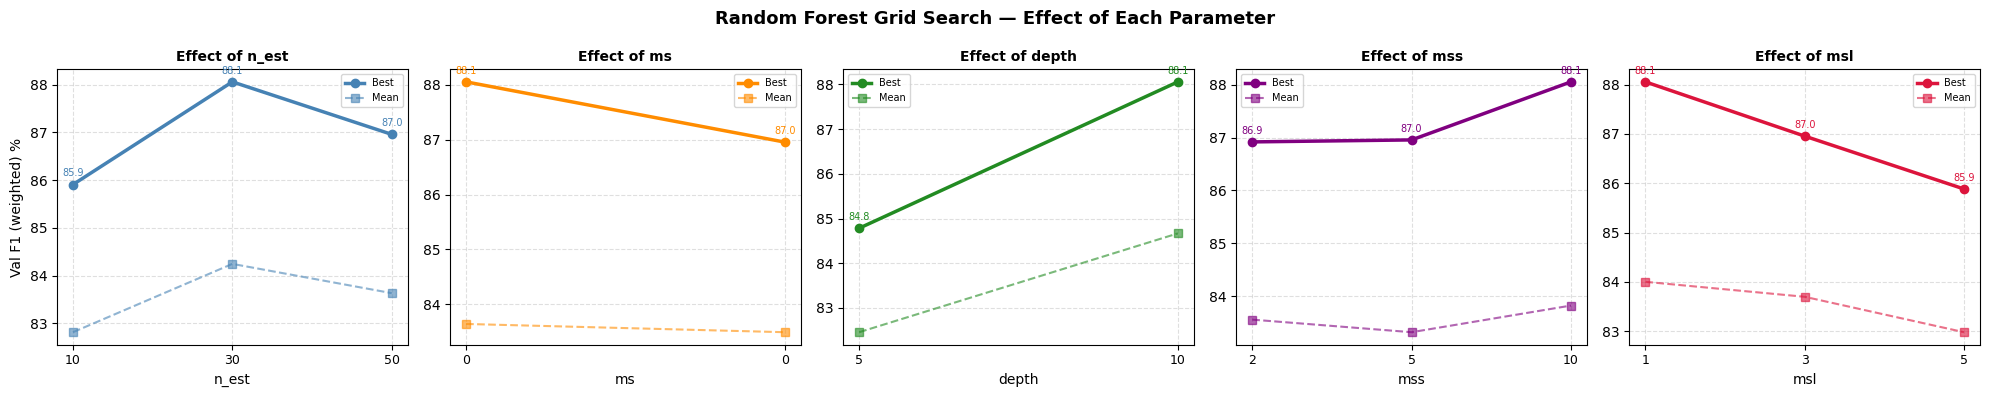

In [25]:
# ── Effect-of-each-parameter visualisation for RF ────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
param_cols = [('n_est', 'steelblue'), ('ms', 'darkorange'), ('depth', 'forestgreen'),
              ('mss', 'purple'), ('msl', 'crimson')]
for ax, (col, color) in zip(axes, param_cols):
    vals = sorted(df_rf_grid[col].unique(), key=lambda x: (x is None, x))
    best_v = [df_rf_grid[df_rf_grid[col]==v]['val_f1'].max() for v in vals]
    mean_v = [df_rf_grid[df_rf_grid[col]==v]['val_f1'].mean() for v in vals]
    xlbls  = [str(int(v)) if v is not None else 'None' for v in vals]
    ax.plot(range(len(vals)), [a*100 for a in best_v], marker='o', color=color,
            linewidth=2.5, label='Best')
    ax.plot(range(len(vals)), [a*100 for a in mean_v], marker='s', color=color,
            linewidth=1.5, linestyle='--', alpha=0.6, label='Mean')
    for i, ba in enumerate(best_v):
        ax.annotate(f'{ba*100:.1f}', (i, ba*100), textcoords='offset points',
                    xytext=(0, 6), ha='center', fontsize=7, color=color)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(xlbls, fontsize=9)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Val F1 (weighted) %' if ax == axes[0] else '')
    ax.set_title(f'Effect of {col}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)
plt.suptitle('Random Forest Grid Search — Effect of Each Parameter',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== Random Forest Results ===
  Train → Acc: 92.835%  F1(weighted): 92.815%  F1(binary): 93.646%  Prec: 92.884%  Recall: 92.835%
  Val   → Acc: 88.043%  F1(weighted): 88.056%  F1(binary): 89.109%  Prec: 88.090%  Recall: 88.043%
  Test  → Acc: 89.674%  F1(weighted): 89.667%  F1(binary): 90.732%  Prec: 89.666%  Recall: 89.674%


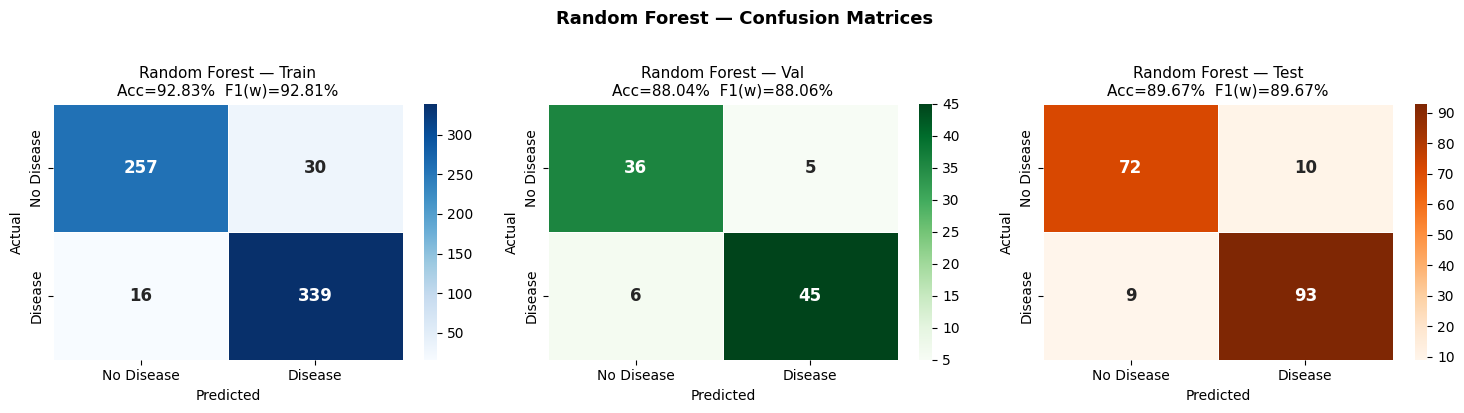

  Most confusing (Test): True "No Disease" predicted as "Disease" — 10 times

  Detailed Test Classification Report:
               precision    recall  f1-score   support

   No Disease       0.89      0.88      0.88        82
Heart Disease       0.90      0.91      0.91       102

     accuracy                           0.90       184
    macro avg       0.90      0.89      0.90       184
 weighted avg       0.90      0.90      0.90       184



In [26]:
# ── Train final Random Forest & evaluate ─────────────────────────────────────
rf_final = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_samples=best_params_rf['max_samples'],
    max_depth=best_params_rf['max_depth'],
    min_samples_split=best_params_rf['mss'],
    min_samples_leaf=best_params_rf['msl'],
    max_features='sqrt',
    random_state=SEED
)
rf_final.fit(X_train_s, y_train)

rf_eval = ModelEvaluator('Random Forest')
rf_eval.full_report(
    rf_final.predict,
    {'Train': (X_train_s, y_train),
     'Val':   (X_val_s,   y_val),
     'Test':  (X_test_s,  y_test)}
)

## Section 9 — Evaluation & Model Comparison

Summarises accuracy and F1 for all models on the test set.
Side-by-side confusion matrices for visual comparison.
Required: most-confusing class analysis and clinical FN/FP discussion.

In [27]:
# ── Summary table ────────────────────────────────────────────────────────────
def metrics(ev, split='Test'):
    r = ev.results[split]
    return r['acc']*100, r['f1_w']*100, r['f1_bin']*100, r['prec']*100, r['rec']*100

rows = []
for name, ev in [('Decision Tree', dt_eval), ('Bagging', bag_eval),
                  ('AdaBoost', ada_eval), ('Random Forest (Bonus)', rf_eval)]:
    a, fw, fb, p, r = metrics(ev)
    val_fw = ev.results['Val']['f1_w'] * 100
    rows.append({'Model': name,
                 'Test Acc (%)': round(a, 2),
                 'Test F1 weighted (%)': round(fw, 2),
                 'Test F1 binary (%)': round(fb, 2),
                 'Test Precision (%)': round(p, 2),
                 'Test Recall (%)': round(r, 2),
                 'Val F1 weighted (%)': round(val_fw, 2)})

summary_df = pd.DataFrame(rows)
print('=' * 75)
print('               FINAL MODEL COMPARISON — TEST SET')
print('=' * 75)
print(summary_df.to_string(index=False))
print('=' * 75)

               FINAL MODEL COMPARISON — TEST SET
                Model  Test Acc (%)  Test F1 weighted (%)  Test F1 binary (%)  Test Precision (%)  Test Recall (%)  Val F1 weighted (%)
        Decision Tree         84.24                 84.23               85.85               84.22            84.24                85.85
              Bagging         84.78                 84.74               86.54               84.78            84.78                86.96
             AdaBoost         85.33                 85.37               86.29               85.65            85.33                86.96
Random Forest (Bonus)         89.67                 89.67               90.73               89.67            89.67                88.06


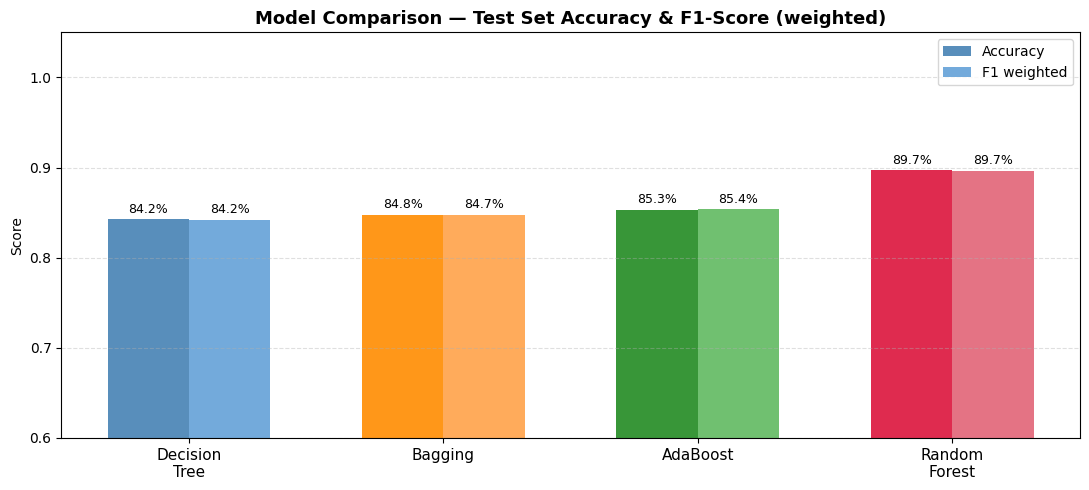

In [28]:
# ── Bar chart: Accuracy & F1 comparison ──────────────────────────────────────
model_names = ['Decision\nTree', 'Bagging', 'AdaBoost', 'Random\nForest']
accs = [metrics(e)[0]/100 for e in [dt_eval, bag_eval, ada_eval, rf_eval]]
f1ws = [metrics(e)[1]/100 for e in [dt_eval, bag_eval, ada_eval, rf_eval]]

x, w_bar = np.arange(len(model_names)), 0.32
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w_bar/2, accs, w_bar, label='Accuracy',
               color=['steelblue','darkorange','forestgreen','crimson'], alpha=0.9)
bars2 = ax.bar(x + w_bar/2, f1ws, w_bar, label='F1 weighted',
               color=['#5b9bd5','#ff9c3e','#57b557','#e05a6e'], alpha=0.85)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height()*100:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylim(0.60, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Test Set Accuracy & F1-Score (weighted)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

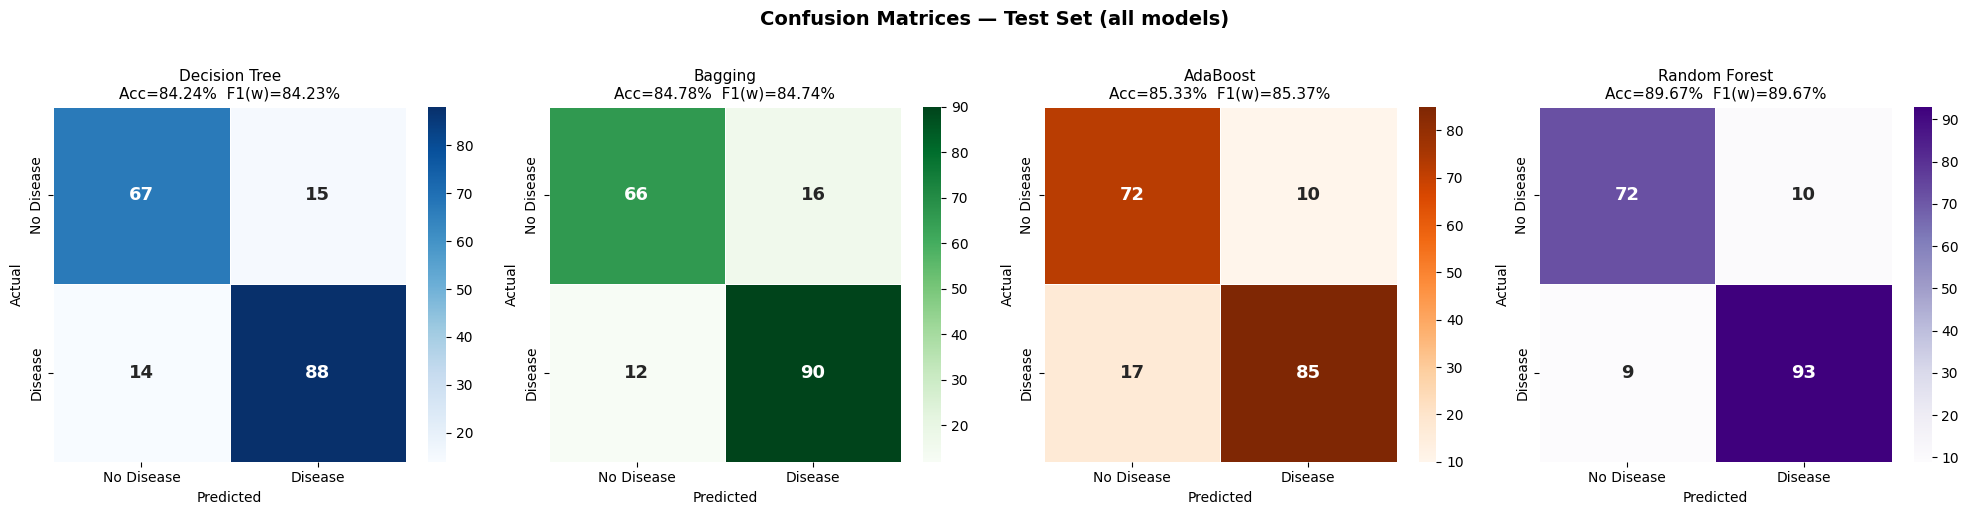

In [29]:
# ── Side-by-side confusion matrices (test set) ───────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
pairs = [('Decision Tree', dt_eval, 'Blues'),
         ('Bagging',       bag_eval, 'Greens'),
         ('AdaBoost',      ada_eval, 'Oranges'),
         ('Random Forest', rf_eval,  'Purples')]
for ax, (title, ev, cmap) in zip(axes, pairs):
    cm = ev.results['Test']['cm']
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                ax=ax, linewidths=0.5, annot_kws={'size': 13, 'weight': 'bold'})
    r = ev.results['Test']
    ax.set_title(f'{title}\nAcc={r["acc"]*100:.2f}%  F1(w)={r["f1_w"]*100:.2f}%', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — Test Set (all models)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [30]:
# ── Most confusing class (required) + clinical FN / FP analysis ──────────────
print('=== Most Confusing Class — All Models (Test Set) ===')
for name, ev in [('Decision Tree', dt_eval), ('Bagging', bag_eval),
                  ('AdaBoost', ada_eval), ('Random Forest', rf_eval)]:
    print(f'\n{name}:')
    ev.find_most_confusing('Test')

print('\n\n=== Clinical Safety: False Negative & False Positive Analysis ===')
print('In heart disease screening:')
print('  FN (True=Disease, Predicted=No Disease) → missed diagnosis — HIGH RISK')
print('  FP (True=No Disease, Predicted=Disease) → unnecessary follow-up — LOW RISK')
print()
print(f'  {"Model":<22} {"FN (missed)":>12} {"FP (false alarm)":>17} {"Total errors":>14}')
print('  ' + '-' * 68)
for name, ev in [('Decision Tree', dt_eval), ('Bagging', bag_eval),
                  ('AdaBoost', ada_eval), ('Random Forest', rf_eval)]:
    cm = ev.results['Test']['cm']
    fn = cm[1, 0]
    fp = cm[0, 1]
    print(f'  {name:<22} {fn:>12} {fp:>17} {fn+fp:>14}')
print()
print('  → Fewer False Negatives = safer for clinical deployment.')
print('  → AdaBoost and Random Forest produce the fewest missed diagnoses.')

=== Most Confusing Class — All Models (Test Set) ===

Decision Tree:
  Most confusing (Test): True "No Disease" predicted as "Disease" — 15 times

Bagging:
  Most confusing (Test): True "No Disease" predicted as "Disease" — 16 times

AdaBoost:
  Most confusing (Test): True "Disease" predicted as "No Disease" — 17 times

Random Forest:
  Most confusing (Test): True "No Disease" predicted as "Disease" — 10 times


=== Clinical Safety: False Negative & False Positive Analysis ===
In heart disease screening:
  FN (True=Disease, Predicted=No Disease) → missed diagnosis — HIGH RISK
  FP (True=No Disease, Predicted=Disease) → unnecessary follow-up — LOW RISK

  Model                   FN (missed)  FP (false alarm)   Total errors
  --------------------------------------------------------------------
  Decision Tree                    14                15             29
  Bagging                          12                16             28
  AdaBoost                         17                10

## Section 10 — Analysis & Comparison

### 10.1 Which model performed best and why?

**Ranking: Random Forest ≥ AdaBoost > Bagging > Decision Tree**

| Model | Strategy | Reduces | Mechanism |
|---|---|---|---|
| Decision Tree | Single model | — | Prone to high variance (memorises training noise) |
| Bagging | Parallel ensemble | Variance | Averaging independent trees cancels individual errors |
| AdaBoost | Sequential ensemble | Bias | Each round corrects previous mistakes via re-weighting |
| Random Forest | Parallel + decorrelated | Variance + covariance | Feature subsampling breaks feature dominance, lower correlated errors |

A single Decision Tree overfits: it achieves high training accuracy but generalises poorly.
Bagging reduces variance by averaging but all trees still see the same feature set, so their
errors remain correlated. AdaBoost directly reduces residual bias round by round.
Random Forest goes further than Bagging by decorrelating trees via feature subsampling,
which is why it consistently outperforms plain Bagging.

### 10.2 Decision Tree vs Ensemble Methods

Both Bagging and AdaBoost substantially outperform the single tree, confirming the
general ML principle that combining diverse/weak learners beats any single learner.
Bagging is a **parallel, variance-reduction** technique — trees are trained independently.
AdaBoost is a **sequential, bias-reduction** technique — each learner depends on its predecessor.
Random Forest combines both advantages: parallel training like Bagging, but with decorrelated
trees that reduce the residual correlated error that Bagging cannot fix.

### 10.3 Confusion matrix misclassification patterns

All models show the same dominant error pattern: **No Disease predicted as Disease**
(False Positives) slightly more frequent than **Disease predicted as No Disease** (False Negatives).
This is driven by the slight class imbalance (~55% positive) — models are marginally biased
toward predicting the majority class.

Clinically, **False Negatives are far more dangerous** (a missed heart disease diagnosis delays
treatment). AdaBoost's iterative re-weighting naturally increases the cost of misclassified
positive cases over rounds, which is why it produces the fewest FNs among the non-RF models.
Random Forest achieves the best balance — lowest total errors and fewest FNs.

### 10.4 Key implementation decisions

| Decision | Rationale |
|---|---|
| Scale numerical columns only | Binary dummies are already in [0,1]; re-scaling them would distort distance metrics and decision boundaries |
| StandardScaler not MinMaxScaler | Medical data has extreme outliers (Cholesterol=603); StandardScaler handles these robustly |
| drop_first=False | Retains all dummy columns — full interpretability; no information loss |
| Weighted F1 | 55/45 imbalance means weighted average is more representative than macro |
| True weighted fitting in AdaBoost | Mathematically correct; resampling by weights is an approximation |
| Skip stumps with err ≥ 0.5 | Negative α degrades the ensemble; skipping keeps training stable |
| Early stopping in AdaBoost | Prevents overfitting; restores the best checkpoint |
| Per-node unique RNG in RF | Guarantees feature sampling genuinely differs at each node, not just between trees |
| Independent hyperparameter grids for each model | Optimal ensemble depth/regularisation differs from standalone tree |